<div align="center">
<h1>03 — Full Modeling: DINOv3 + KEC + DROWCULA</h1>
<p>Perjalanan citra e-waste menjadi 17 klaster final: tiap tahap menampilkan masukannya, prosesnya, dan keluarannya.</p>
</div>

## ***Setup***
---
Menyiapkan import ringan CPU, seed 42, dan path repo dari artefak cache.

Import pustaka dan mengunci seed agar seluruh tabel dan plot dapat direproduksi.

In [1]:
import random, json, re, hashlib
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from collections import Counter
from IPython.display import Image as NBImage, display as nbdisplay

random.seed(42); np.random.seed(42)
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 120})
plt.ioff()

ROOT = Path.cwd()
while not (ROOT / "AGENTS.md").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
PROC = ROOT / "data" / "processed" / "electronic"
KEC = PROC / "kec_drowcula_dinov3"
FIG = KEC / "figures"
AUD = KEC / "caption_audit_v1"
print("ROOT:", ROOT)
print("numpy", np.__version__, "| pandas", pd.__version__, "| matplotlib", matplotlib.__version__)


ROOT: /home/varys/orca/workspaces/2026_SatriaData_SemiFinal/DROWCULA-MODELLING
numpy 2.3.5 | pandas 3.0.3 | matplotlib 3.11.0


## ***Data***
---
Memeriksa kelengkapan manifest, keselarasan urutan embedding, dan keberadaan file citra di disk.

Meringkas jumlah baris tiap berkas dan kecocokan basename label relatif terhadap path absolut embedding.

In [2]:
manifest = pd.read_csv(PROC / "manifest_train.csv")
labels = pd.read_csv(KEC / "labels.csv")
ids = pd.read_csv(PROC / "embedding_ids.csv")
ABS = {Path(str(f)).name: Path(str(f)) for f in ids["filepath"]}
base_rel = set(Path(str(f)).name for f in labels["filepath"])
found = sum(1 for p in ABS.values() if p.exists())
pd.DataFrame([
    {"cek": "baris manifest", "nilai": len(manifest)},
    {"cek": "baris labels K=17 terkunci", "nilai": len(labels)},
    {"cek": "baris embedding_ids", "nilai": len(ids)},
    {"cek": "basename labels == ids", "nilai": base_rel == set(ABS)},
    {"cek": "citra ditemukan di disk", "nilai": f"{found}/{len(ABS)}"},
    {"cek": "kelas sumber", "nilai": sorted(manifest["source_class"].unique().tolist())},
])


,cek,nilai
0,baris manifest,3961
1,baris labels K=17 terkunci,3961
2,baris embedding_ids,3961
3,basename labels == ids,True
4,citra ditemukan di disk,3961/3961
5,kelas sumber,[1_Electronic]


Memetakan basename ke path absolut agar interval sel citra dapat dibuka langsung dari cache.

In [3]:
def img_path(rel):
    name = Path(str(rel)).name
    p = ABS.get(name)
    if p is not None and p.exists():
        return p
    q = ROOT / str(rel)
    return q if q.exists() else None


Menampilkan 9 citra acak beserta klaster akhirnya sebagai gambaran keragaman visual sebelum ekstraksi fitur.

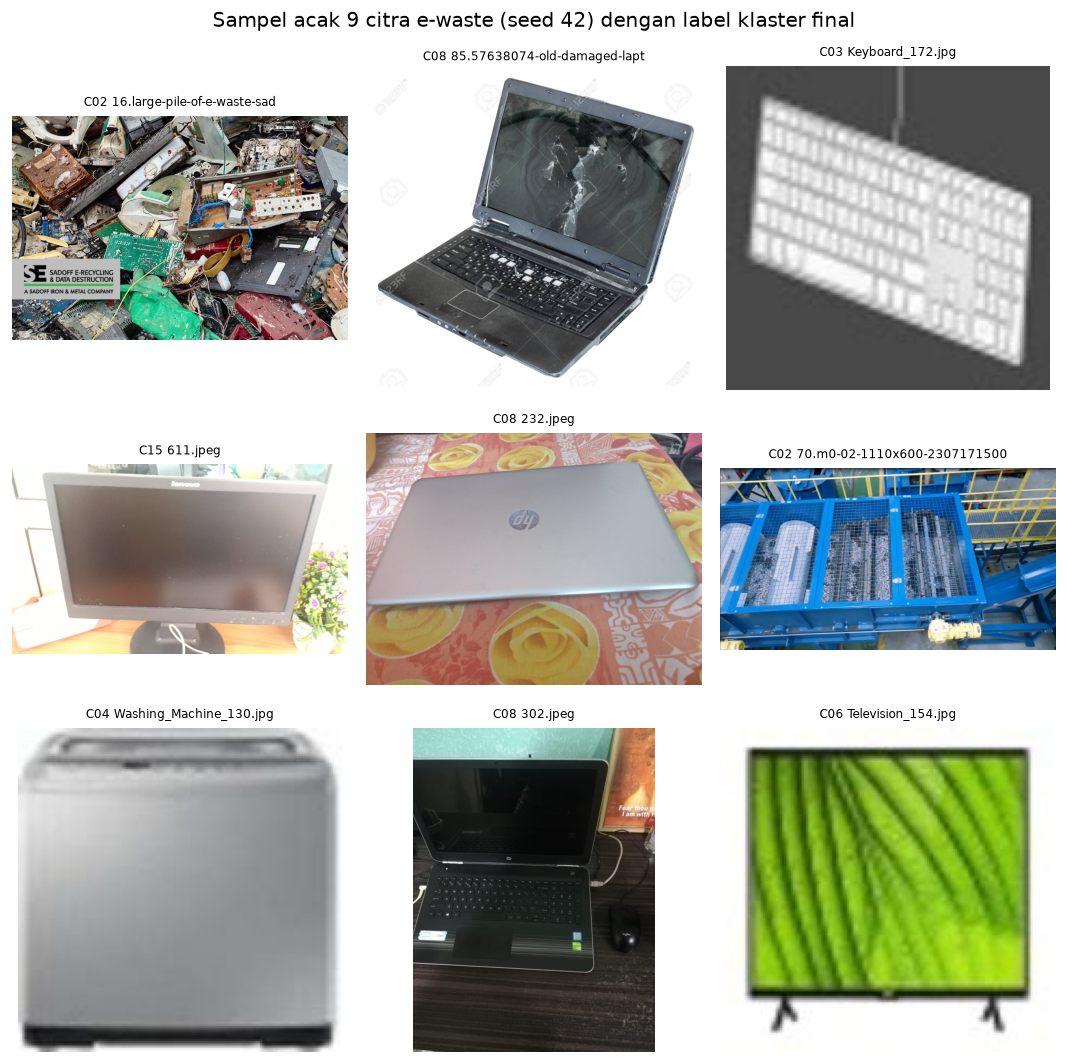

In [4]:
sample = labels.sample(9, random_state=42)
fig, axes = plt.subplots(3, 3, figsize=(9, 9))
for ax, (_, r) in zip(axes.flat, sample.iterrows()):
    ax.axis("off")
    p = img_path(r["filepath"])
    if p is None:
        ax.set_title("missing", fontsize=8)
        continue
    ax.imshow(Image.open(p).convert("RGB"))
    ax.set_title(f'C{int(r["cluster"]):02d} {Path(str(r["filepath"])).name[:28]}', fontsize=7)
fig.suptitle("Sampel acak 9 citra e-waste (seed 42) dengan label klaster final")
fig.tight_layout()
plt.show(fig)


Menghitung awalan nama file untuk melihat kelompok visual kasar yang sudah terbawa sejak pengumpulan data.

In [5]:
names = [Path(str(f)).name for f in manifest["filepath"]]
pref = []
for n in names:
    m = re.match(r"^([A-Za-z]+)", n)
    pref.append(m.group(1) if m else "other")
t = pd.DataFrame(Counter(pref).most_common(15), columns=["awalan_nama", "jumlah"])
t


,awalan_nama,jumlah
0,other,1041
1,Television,300
2,Washing,300
3,Mobile,291
4,Printer,279
5,Mouse,265
6,Microwave,259
7,Keyboard,258
8,Player,258
9,pcb,230


## ***Backbone Visual DINOv3***
---
Memuat embedding DINOv3 ViT-B/16 dari cache dan mengukur statistiknya sebelum normalisasi.

Menampilkan dimensi, sebaran nilai, dan norma baris mentah yang menjadi alasan tahap L2.

In [6]:
d = np.load(PROC / "embeddings_dinov3.npy").astype(np.float64)
nr = np.linalg.norm(d, axis=1)
pd.DataFrame([{"N": d.shape[0], "dimensi": d.shape[1], "rerata": round(float(d.mean()), 6),
               "std": round(float(d.std()), 6), "min": round(float(d.min()), 3),
               "max": round(float(d.max()), 3), "rerata_norma_baris": round(float(nr.mean()), 2),
               "std_norma_baris": round(float(nr.std()), 3)}])
del d, nr


Menggambar histogram norma baris mentah untuk membuktikan geometri cosine belum berlaku tanpa L2.

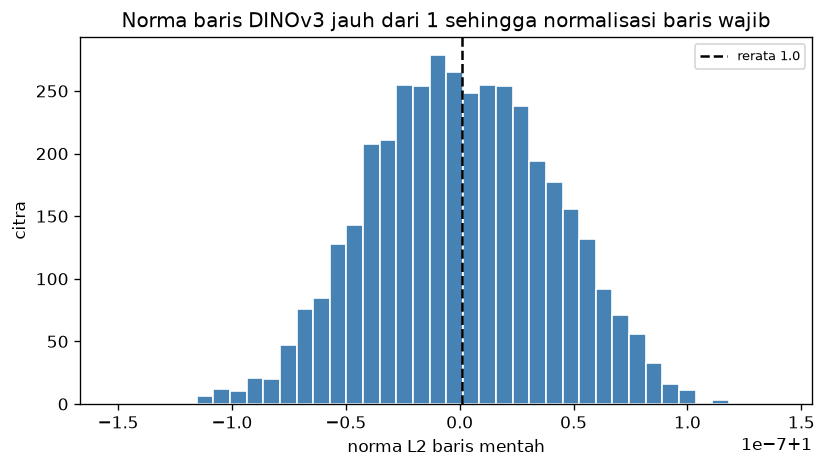

In [7]:
d = np.load(PROC / "embeddings_dinov3.npy").astype(np.float64)
nr = np.linalg.norm(d, axis=1)
del d
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(nr, bins=40, color="steelblue", edgecolor="white")
ax.axvline(nr.mean(), ls="--", c="k", label=f"rerata {nr.mean():.1f}")
ax.set_xlabel("norma L2 baris mentah"); ax.set_ylabel("citra"); ax.legend(fontsize=8)
ax.set_title("Norma baris DINOv3 jauh dari 1 sehingga normalisasi baris wajib")
fig.tight_layout()
plt.show(fig)


## ***KEC Tahap 1: WordNet dan Over-Cluster***
---
Membangun kandidat kata umum WordNet yang sudah dibersihkan sebagai fondasi jembatan citra-teks.

Menampilkan ukuran kosakata, aturan pembersihan, dan contoh entri di tengah daftar alfabetis.

In [8]:
nouns = json.load(open(KEC / "noun_list.json"))
tok = [len(w.split()) for w in nouns]
pd.DataFrame([{"noun_total": len(nouns), "aturan": "huruf kecil, >=3 huruf, maks 3 kata, huruf/spasi/strip",
               "contoh": ", ".join(nouns[2000:2006]),
               "satu_kata": sum(1 for t in tok if t == 1), "dua_kata": sum(1 for t in tok if t == 2),
               "tiga_kata": sum(1 for t in tok if t == 3)}])


,noun_total,aturan,contoh,satu_kata,dua_kata,tiga_kata
0,113964,"huruf kecil, >=3 huruf, maks 3 kata, huruf/spa...","airfare, airfield, airflow, airfoil, airforce,...",56902,50451,6611


Menggambar komposisi kosakata per jumlah kata untuk menunjukkan dominasi frasa pendek.

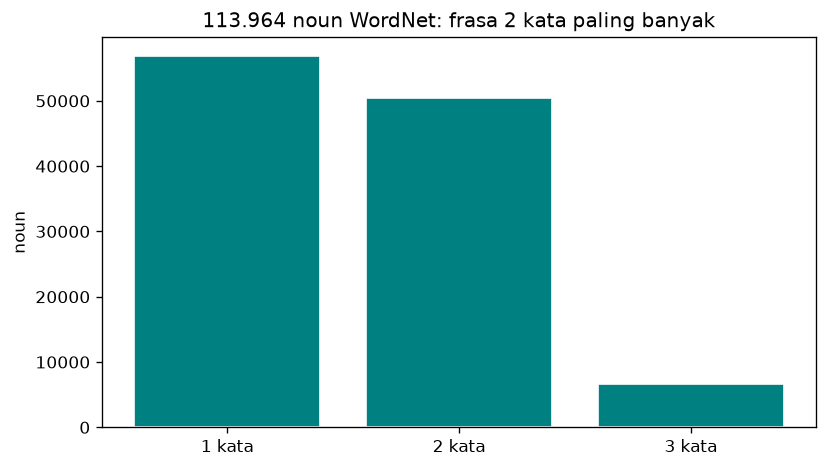

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(["1 kata", "2 kata", "3 kata"], [sum(1 for t in tok if t == 1), sum(1 for t in tok if t == 2), sum(1 for t in tok if t == 3)], color="teal", edgecolor="white")
ax.set_ylabel("noun"); ax.set_title("113.964 noun WordNet: frasa 2 kata paling banyak")
fig.tight_layout()
plt.show(fig)


Menghitung over-cluster ruang citra SigLIP2 dengan k = round(3961/300) = 13 sebagai unit pemetaan noun.

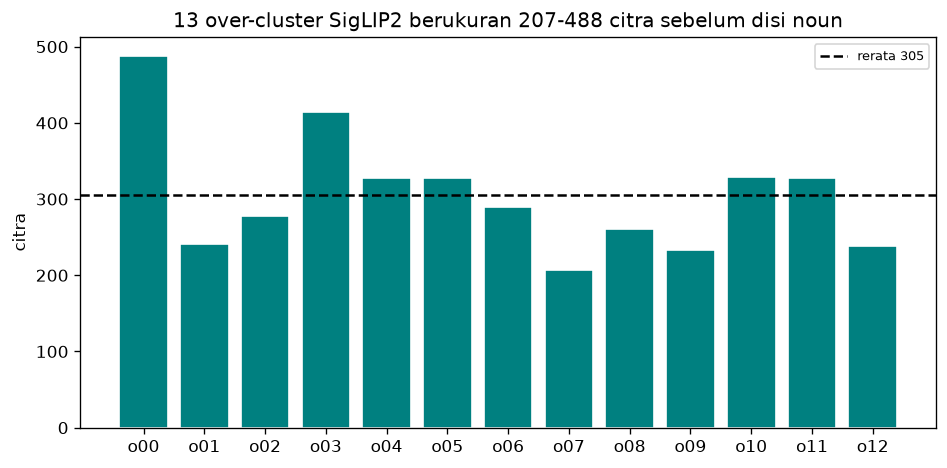

In [10]:
z = np.load(KEC / "over_clusters.npz")
k_over = int(z["k_over"])
sizes = np.bincount(z["labels_over"].astype(int))
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar([f"o{i:02d}" for i in range(k_over)], sizes, color="teal", edgecolor="white")
ax.axhline(sizes.mean(), ls="--", c="k", label=f"rerata {sizes.mean():.0f}")
ax.set_ylabel("citra"); ax.legend(fontsize=8)
ax.set_title("13 over-cluster SigLIP2 berukuran 207-488 citra sebelum disi noun")
fig.tight_layout()
plt.show(fig)


Menampilkan 5 noun teratas tiap centroid versi cosine sebagai hasil persamaan pemetaan KEC.

In [11]:
npc = json.load(open(KEC / "nouns_per_cluster.json"))
rows = []
for c in sorted(npc, key=int):
    for rank, d in enumerate(npc[c], start=1):
        rows.append({"overcluster": f"o{int(c):02d}", "rank": rank, "noun": d["noun"], "cosine": round(d["score"], 4)})
pd.DataFrame(rows)


,overcluster,rank,noun,cosine
0,o00,1,cellphone,0.1357
1,o00,2,mobile phone,0.1342
2,o00,3,phone,0.1341
3,o00,4,phoner,0.1297
4,o00,5,note,0.1266
...,...,...,...,...
60,o12,1,cd player,0.1670
61,o12,2,record player,0.1432
62,o12,3,stereo system,0.1415
63,o12,4,recorder player,0.1377


Menggambar skor noun terbaik tiap over-cluster untuk menilai kepercayaan pemetaan yang semuanya rendah.

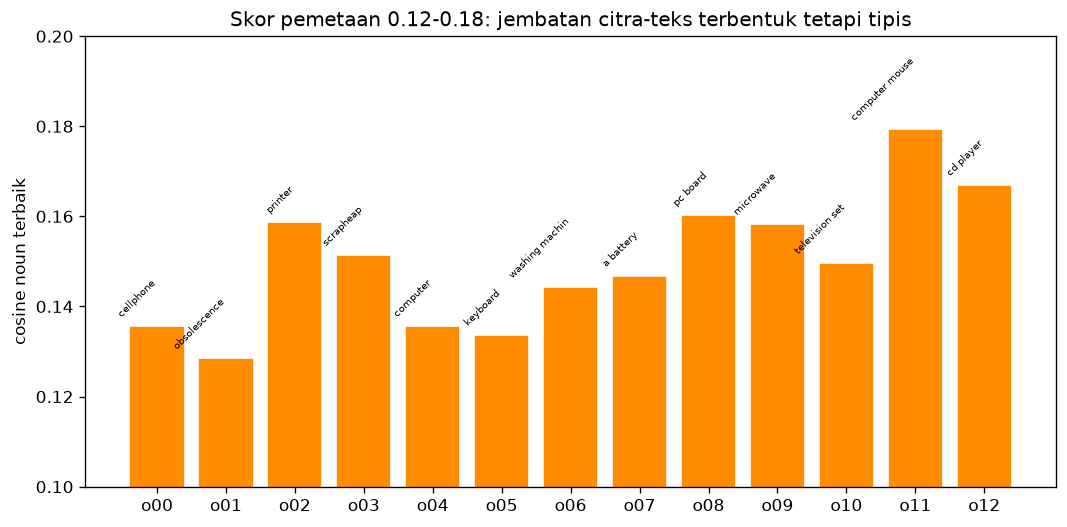

In [12]:
best = [(f'o{int(c):02d}', npc[c][0]["noun"], npc[c][0]["score"]) for c in sorted(npc, key=int)]
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar([b[0] for b in best], [b[2] for b in best], color="darkorange", edgecolor="white")
ax.set_ylim(0.1, 0.2); ax.set_ylabel("cosine noun terbaik")
ax.set_title("Skor pemetaan 0.12-0.18: jembatan citra-teks terbentuk tetapi tipis")
for x, b in zip(range(len(best)), best):
    ax.text(x, b[2] + 0.002, b[1][:14], rotation=45, ha="right", fontsize=6)
fig.tight_layout()
plt.show(fig)


## ***KEC Tahap 2: Konsep dan Atribut***
---
Menggabungkan 13 over-cluster lewat kemiripan multimodal alpha 0.8 dan ambang beta 0.8.

Menampilkan kartu konsep tunggal hasil gabungan sebagai bukti kolaps beta 0.8 di data e-waste.

In [13]:
concepts = json.load(open(KEC / "concepts.json"))
c = concepts[0]
pd.DataFrame([{"konsep": c["concept"], "overcluster_tergabung": f"{len(c['members'])}/13",
               "noun_tergabung": len(c["nouns"]), "model": c["model"],
               "deskripsi": c["description"][:170] + "..."}])


,konsep,overcluster_tergabung,noun_tergabung,model,deskripsi
0,Electronic and Appliance Scrapheap,13/13,65,gpt-4o,A chaotic pile of outdated and broken electron...


Menampilkan atribut visual GPT-4o dan pasangan tetangga yang kosong sebagai konsekuensi satu konsep.

In [14]:
attrs = json.load(open(KEC / "attributes.json"))
nb = json.load(open(KEC / "neighbour_pairs.json"))
q = attrs["q0"]
pd.DataFrame([{"atribut_uni_1": q["uni"][0], "atribut_uni_2": q["uni"][1],
               "atribut_bi": len(q.get("bi", [])), "tetangga_beta": str(nb.get("0"))}])


,atribut_uni_1,atribut_uni_2,atribut_bi,tetangga_beta
0,Tangled mass of multicolored wires and circuit...,Jumbled assortment of metallic and plastic fra...,0,[]


Mengukur kappa hasil grounding dan menyandingkannya dengan blok DINOv3 dan citra SigLIP2.

In [15]:
rows = []
for name, rel in [("dino DINOv3", PROC / "embeddings_dinov3.npy"),
                  ("citra SigLIP2", KEC / "kec_image_embeddings.npy"),
                  ("kappa grounded", KEC / "kappa.npy")]:
    a = np.load(rel).astype(np.float64)
    rows.append({"blok": name, "bentuk": str(a.shape), "rerata": round(float(a.mean()), 6), "std": round(float(a.std()), 5)})
    del a
pd.DataFrame(rows)


,blok,bentuk,rerata,std
0,dino DINOv3,"(3961, 768)",0.000363,0.03608
1,citra SigLIP2,"(3961, 768)",0.001606,0.03605
2,kappa grounded,"(3961, 768)",0.001914,0.03575


Menggambar sebaran nilai DINOv3 dan kappa dari 200 ribu sampel agar bentuknya dapat dibandingkan.

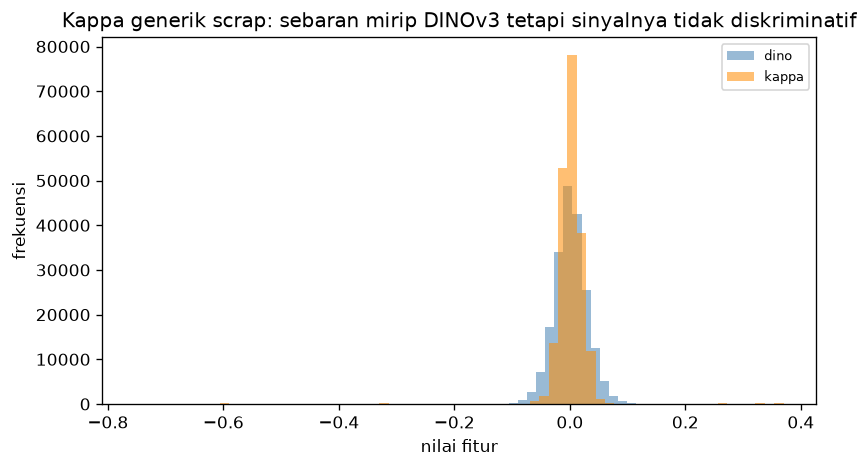

In [16]:
rng = np.random.default_rng(42)
d = np.load(PROC / "embeddings_dinov3.npy").astype(np.float64).ravel()
k = np.load(KEC / "kappa.npy").astype(np.float64).ravel()
ds = rng.choice(d, 200000, replace=False); ks = rng.choice(k, 200000, replace=False)
del d, k
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(ds, bins=60, alpha=0.55, label="dino", color="steelblue")
ax.hist(ks, bins=60, alpha=0.55, label="kappa", color="darkorange")
ax.set_xlabel("nilai fitur"); ax.set_ylabel("frekuensi"); ax.legend(fontsize=8)
ax.set_title("Kappa generik scrap: sebaran mirip DINOv3 tetapi sinyalnya tidak diskriminatif")
fig.tight_layout()
plt.show(fig)


## ***Fusi dan UMAP***
---
Menggabungkan DINOv3 dan kappa setelah L2 mandiri menjadi vektor fusi 1536-D.

Memeriksa norma tiap blok di dalam vektor fusi agar bobot visual dan pengetahuan tepat seimbang.

In [17]:
f = np.load(KEC / "fused_features.npy").astype(np.float64)
db = np.linalg.norm(f[:, :768], axis=1); kb = np.linalg.norm(f[:, 768:], axis=1)
h = hashlib.sha256(open(KEC / "fused_features.npy", "rb").read()).hexdigest()[:16]
pd.DataFrame([{"bentuk_fusi": str(f.shape), "sha": h,
               "norma_blok_dino": round(float(db.mean()), 4), "norma_blok_kappa": round(float(kb.mean()), 4)}])
del f, db, kb


Menampilkan konfigurasi reduksi UMAP cache yang menjadi ruang resmi pencarian K DROWCULA.

In [18]:
cfg = json.load(open(KEC / "reduction_config.json"))
print("masukan:", cfg["input_shape"], "| sidik:", cfg["input_fingerprint_sha256"][:16])
print("komponen:", cfg["n_components"], "| tetangga:", cfg["n_neighbors"], "| min_dist:", cfg["min_dist"], "| metrik:", cfg["metric"])
print("normalisasi:", cfg["normalization"])


masukan: [3961, 1536] | sidik: 5f2bae710fe2a03a
komponen: 3 | tetangga: 10 | min_dist: 0.1 | metrik: euclidean
normalisasi: independent row-wise L2 on DINOv3 and kappa blocks


Memetakan struktur manifold 3-D dalam tiga proyeksi berpasangan sebelum identitas klaster dikenalkan.

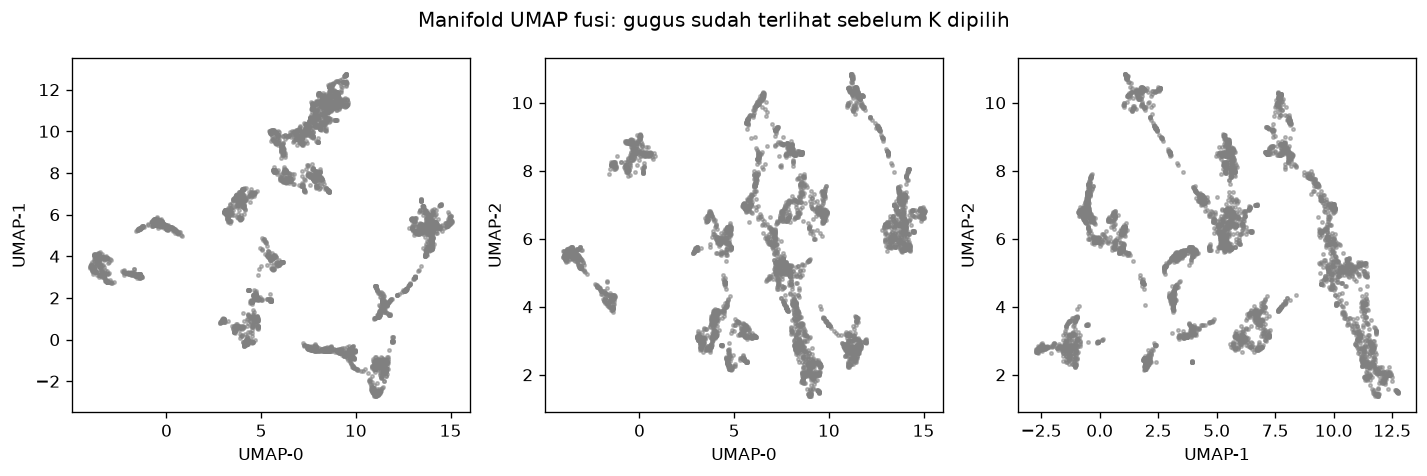

In [19]:
red = np.load(KEC / "reduced_fused_embeddings.npy")
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (i, j) in zip(axes, [(0, 1), (0, 2), (1, 2)]):
    ax.scatter(red[:, i], red[:, j], s=4, alpha=0.5, c="gray")
    ax.set_xlabel(f"UMAP-{i}"); ax.set_ylabel(f"UMAP-{j}")
fig.suptitle("Manifold UMAP fusi: gugus sudah terlihat sebelum K dipilih")
fig.tight_layout()
plt.show(fig)
del red


## ***K-Search DROWCULA***
---
Menjalankan ulang bacaan skor K-Means K=2..25 di ruang UMAP untuk memilih K unknown.

Menampilkan seluruh 24 baris skor agar puncak silhouette dapat diverifikasi manual.

In [20]:
s = pd.read_csv(KEC / "k_search_scores.csv")
show = s.copy()
for c in ["silhouette", "davies_bouldin", "calinski_harabasz", "inertia"]:
    show[c] = show[c].round(4)
show


,k,silhouette,davies_bouldin,calinski_harabasz,inertia,min_cluster_size,max_cluster_size
0,2,0.3919,1.1027,2491.5014,108756.7344,1385,2576
1,3,0.4655,0.8373,3606.1189,62788.2500,1257,1385
2,4,0.4986,0.7552,3777.3277,45861.8555,539,1541
3,5,0.5400,0.7757,4369.5181,32705.1152,539,1252
4,6,0.5469,0.7378,4977.5308,24298.2734,503,785
5,7,0.5723,0.6832,5451.1584,19111.7012,343,785
6,8,0.5993,0.6192,6456.5738,14252.0352,343,749
7,9,0.6229,0.5650,7282.6152,11256.4248,242,749
8,10,0.6523,0.4922,8850.2891,8374.2549,228,749
9,11,0.6461,0.5032,10672.3175,6324.3931,228,524


Menggambar kurva silhouette dan Davies-Bouldin dengan garis K=17 sebagai titik keputusan.

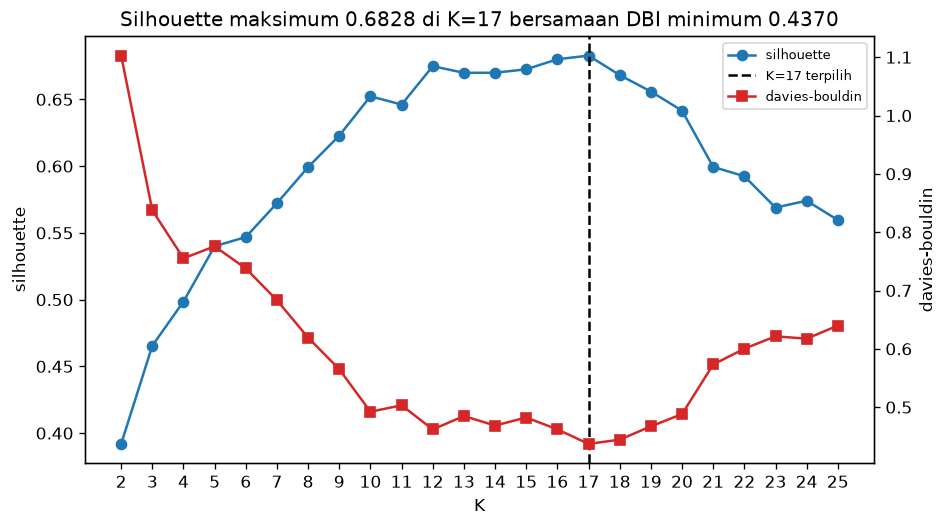

In [21]:
s = pd.read_csv(KEC / "k_search_scores.csv")
fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.plot(s["k"], s["silhouette"], marker="o", label="silhouette")
ax1.axvline(17, ls="--", c="k", label="K=17 terpilih")
ax1.set_xlabel("K"); ax1.set_ylabel("silhouette"); ax1.set_xticks(s["k"])
ax2 = ax1.twinx()
ax2.plot(s["k"], s["davies_bouldin"], marker="s", c="tab:red", label="davies-bouldin")
ax2.set_ylabel("davies-bouldin")
h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, fontsize=8)
ax1.set_title("Silhouette maksimum 0.6828 di K=17 bersamaan DBI minimum 0.4370")
fig.tight_layout()
plt.show(fig)


Menggambar biaya inertia dan ukuran klaster terkecil sebagai kontrol kerapuhan K besar.

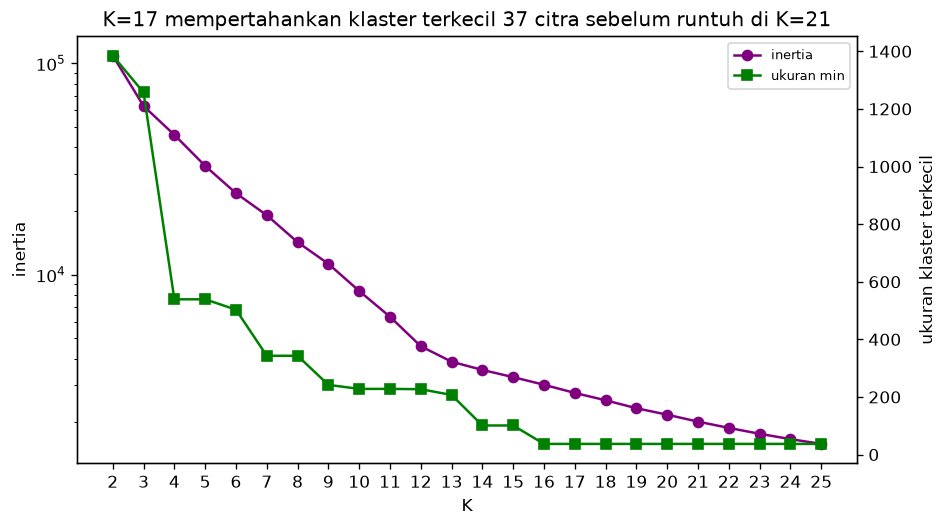

In [22]:
s = pd.read_csv(KEC / "k_search_scores.csv")
fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.plot(s["k"], s["inertia"], marker="o", c="purple", label="inertia")
ax1.set_xlabel("K"); ax1.set_ylabel("inertia"); ax1.set_xticks(s["k"]); ax1.set_yscale("log")
ax2 = ax1.twinx()
ax2.plot(s["k"], s["min_cluster_size"], marker="s", c="green", label="ukuran min")
ax2.set_ylabel("ukuran klaster terkecil")
h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, fontsize=8)
ax1.set_title("K=17 mempertahankan klaster terkecil 37 citra sebelum runtuh di K=21")
fig.tight_layout()
plt.show(fig)


Menampilkan kartu metrik final klaster terpilih dari berkas terkunci sebagai jangkar evaluasi.

In [23]:
m = json.load(open(KEC / "final_metrics.json"))
pd.DataFrame([{"K_terpilih": m["selected_k"], "silhouette": round(m["silhouette"], 4),
               "davies_bouldin": round(m["davies_bouldin"], 4),
               "calinski_harabasz": round(m["calinski_harabasz"], 1),
               "N": m["n_samples"], "ruang": m["selection_space"]}])


,K_terpilih,silhouette,davies_bouldin,calinski_harabasz,N,ruang
0,17,0.6828,0.437,15591.7,3961,UMAP-reduced fused DINOv3+KEC features


## ***Klaster Final***
---
Menggambar distribusi ukuran 17 klaster berlabel nama final manusia.

Batang diurut dari terbesar agar dominasi ponsel dan kelangkaan outlet langsung terbaca.

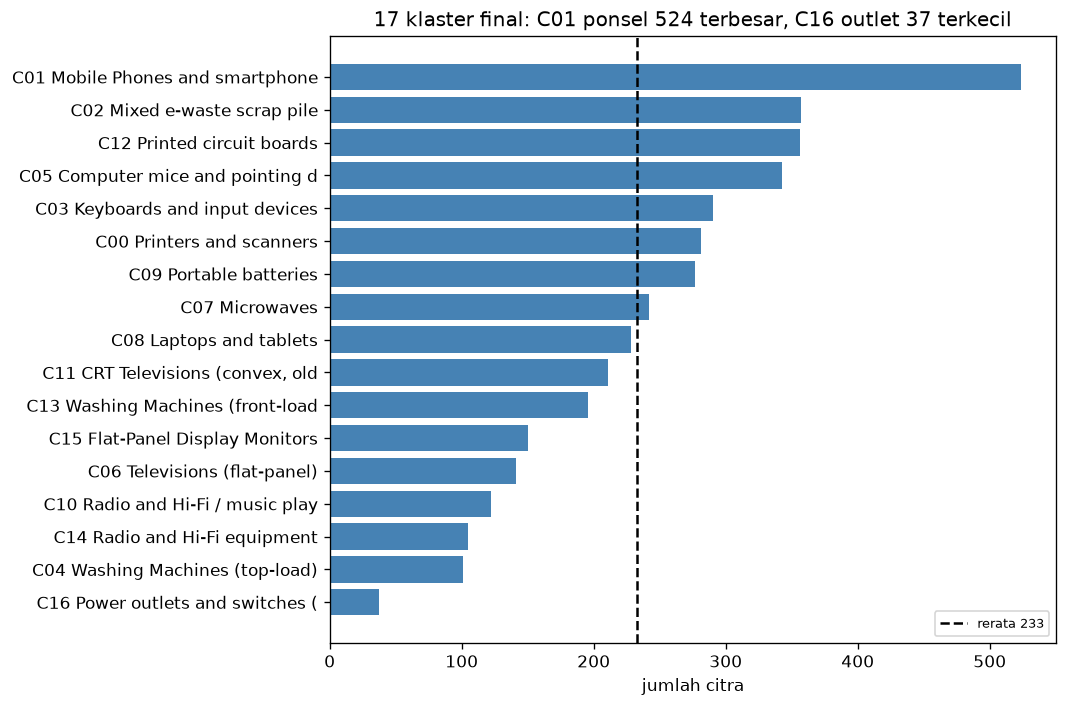

In [24]:
sizes = pd.read_csv(KEC / "cluster_sizes.csv")
final = pd.read_csv(KEC / "final_cluster_labels.csv")
t = sizes.merge(final[["cluster", "final_label"]], on="cluster").sort_values("size")
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh([f'C{r.cluster:02d} {r.final_label[:28]}' for r in t.itertuples()], t["size"], color="steelblue")
ax.axvline(t["size"].mean(), ls="--", c="k", label=f"rerata {t['size'].mean():.0f}")
ax.set_xlabel("jumlah citra"); ax.legend(fontsize=8)
ax.set_title("17 klaster final: C01 ponsel 524 terbesar, C16 outlet 37 terkecil")
fig.tight_layout()
plt.show(fig)


Memetakan 3961 titik UMAP dengan warna identitas klaster sebagai bukti pemisahan visual.

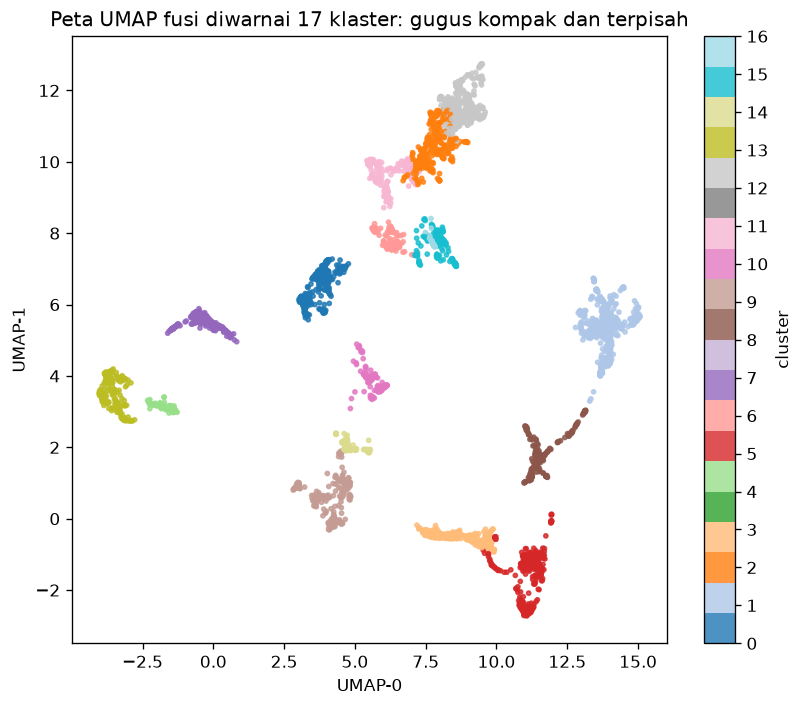

In [25]:
red = np.load(KEC / "reduced_fused_embeddings.npy")
lab = labels["cluster"].to_numpy()
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(red[:, 0], red[:, 1], c=lab, cmap="tab20", s=6, alpha=0.8)
cbar = fig.colorbar(sc, ax=ax, ticks=range(17))
cbar.set_label("cluster")
ax.set_xlabel("UMAP-0"); ax.set_ylabel("UMAP-1")
ax.set_title("Peta UMAP fusi diwarnai 17 klaster: gugus kompak dan terpisah")
fig.tight_layout()
plt.show(fig)
del red


Menampilkan grid perangkat kecil: printer, keyboard, dan mouse yang menjadi tulang punggung Small IT.

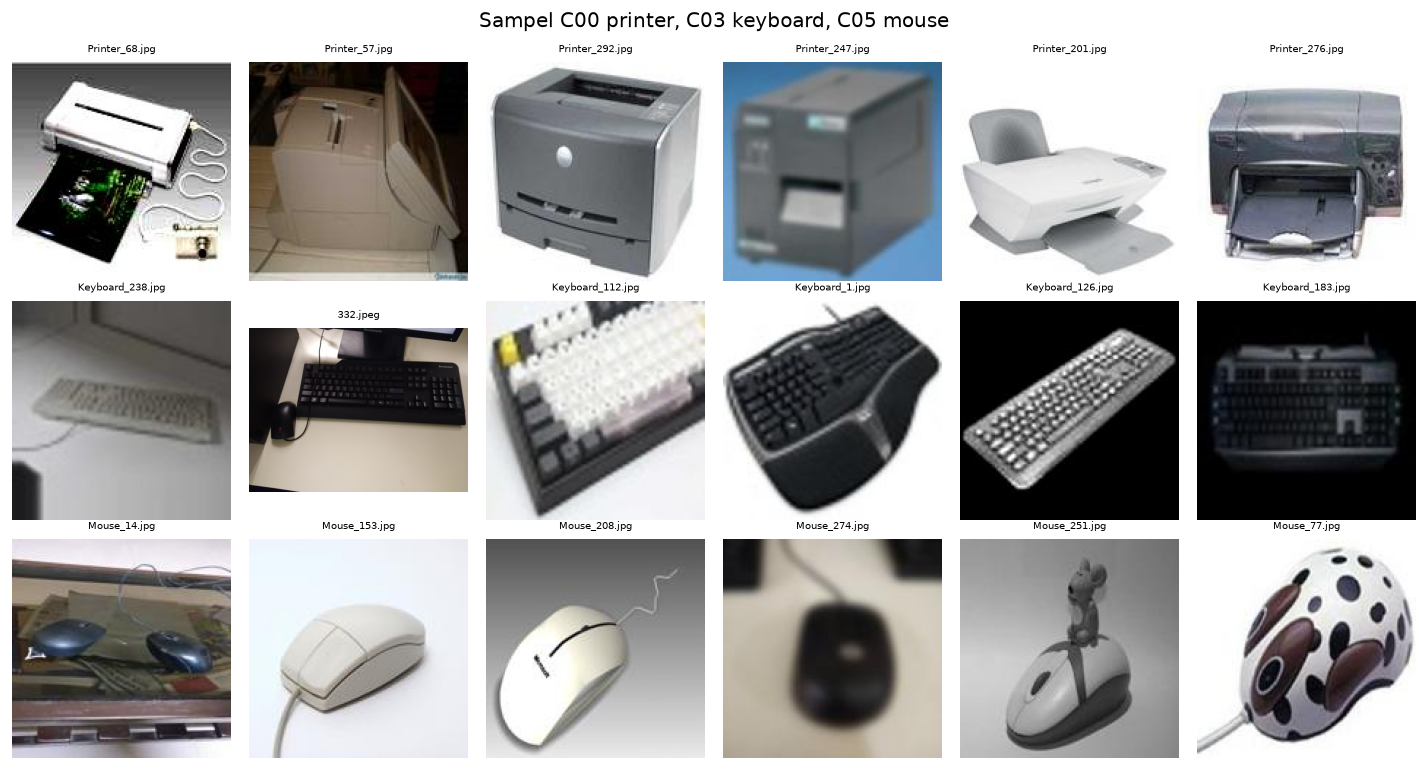

In [26]:
pick = [0, 3, 5]
fig, axes = plt.subplots(3, 6, figsize=(12, 6.5))
for row, c in zip(axes, pick):
    sub = labels[labels["cluster"] == c].sample(6, random_state=7)
    for ax, (_, r) in zip(row, sub.iterrows()):
        ax.axis("off")
        p = img_path(r["filepath"])
        if p is None:
            ax.set_title("missing", fontsize=7)
            continue
        ax.imshow(Image.open(p).convert("RGB"))
        ax.set_title(Path(str(r["filepath"])).name[:20], fontsize=6)
    row[0].set_ylabel(f"C{c:02d}", fontsize=10)
fig.suptitle("Sampel C00 printer, C03 keyboard, C05 mouse")
fig.tight_layout()
plt.show(fig)


Menampilkan grid alat besar: dua varian mesin cuci dan microwave yang sering tertukar model teks.

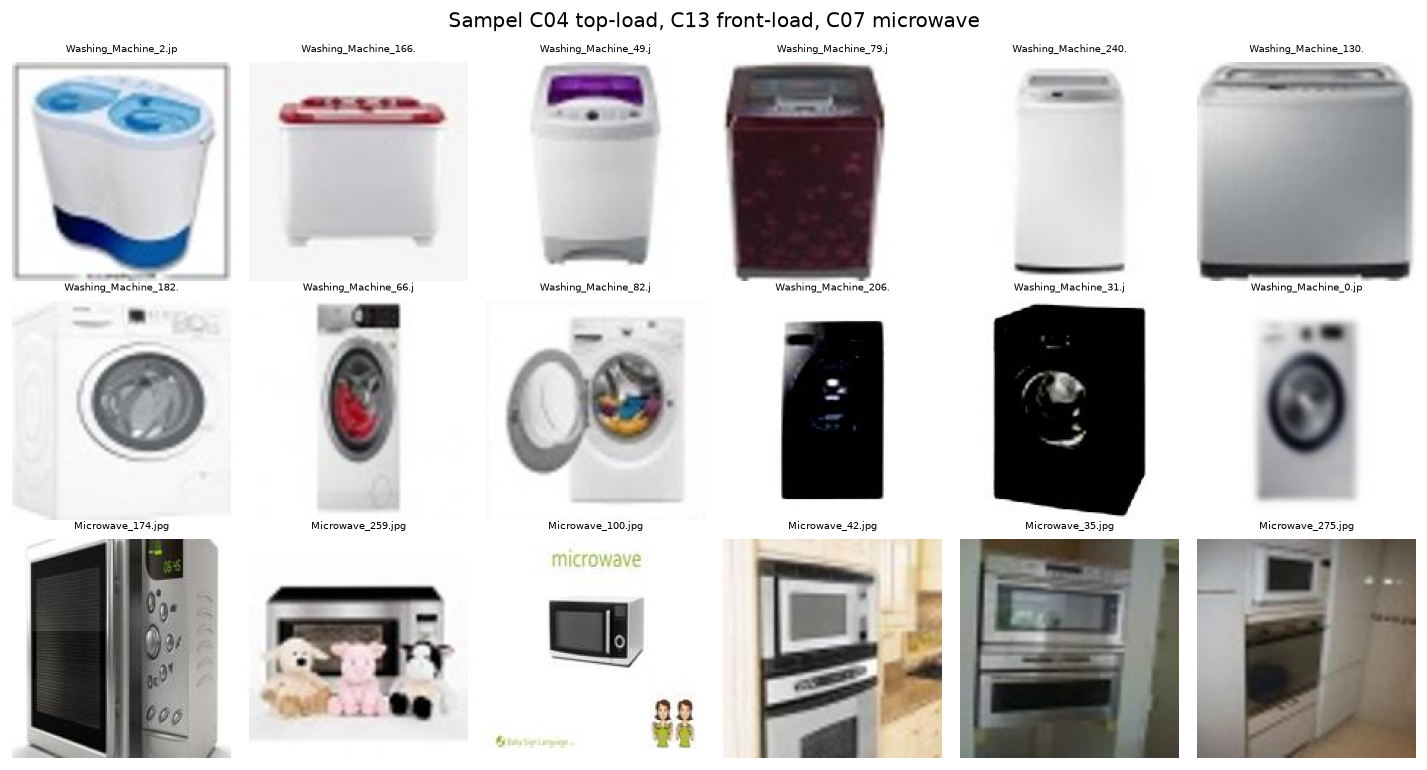

In [27]:
pick = [4, 13, 7]
fig, axes = plt.subplots(3, 6, figsize=(12, 6.5))
for row, c in zip(axes, pick):
    sub = labels[labels["cluster"] == c].sample(6, random_state=7)
    for ax, (_, r) in zip(row, sub.iterrows()):
        ax.axis("off")
        p = img_path(r["filepath"])
        if p is None:
            ax.set_title("missing", fontsize=7)
            continue
        ax.imshow(Image.open(p).convert("RGB"))
        ax.set_title(Path(str(r["filepath"])).name[:20], fontsize=6)
    row[0].set_ylabel(f"C{c:02d}", fontsize=10)
fig.suptitle("Sampel C04 top-load, C13 front-load, C07 microwave")
fig.tight_layout()
plt.show(fig)


Menampilkan grid layar dan aliran khusus: laptop, CRT convex, dan PCB bernilai tinggi.

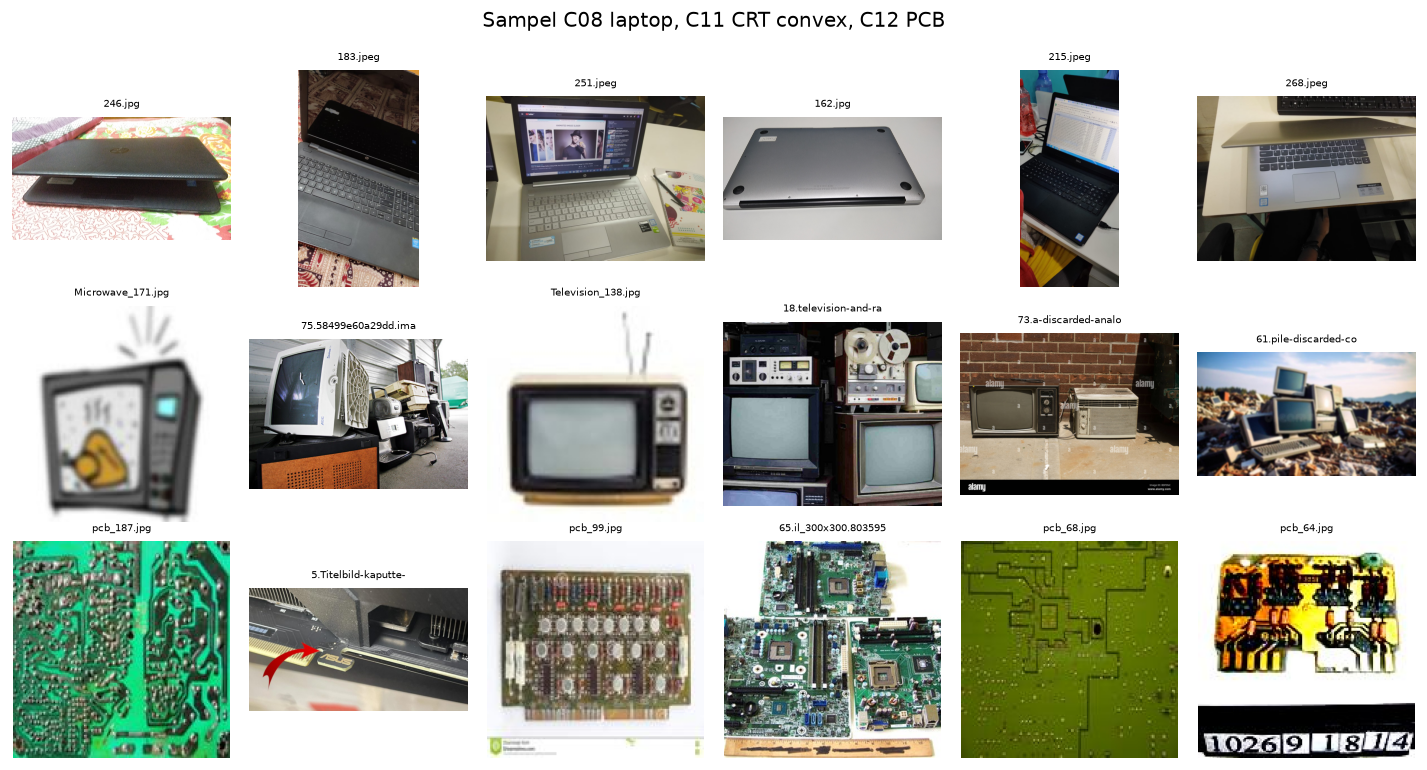

In [28]:
pick = [8, 11, 12]
fig, axes = plt.subplots(3, 6, figsize=(12, 6.5))
for row, c in zip(axes, pick):
    sub = labels[labels["cluster"] == c].sample(6, random_state=7)
    for ax, (_, r) in zip(row, sub.iterrows()):
        ax.axis("off")
        p = img_path(r["filepath"])
        if p is None:
            ax.set_title("missing", fontsize=7)
            continue
        ax.imshow(Image.open(p).convert("RGB"))
        ax.set_title(Path(str(r["filepath"])).name[:20], fontsize=6)
    row[0].set_ylabel(f"C{c:02d}", fontsize=10)
fig.suptitle("Sampel C08 laptop, C11 CRT convex, C12 PCB")
fig.tight_layout()
plt.show(fig)


## ***Kesimpulan***
---
Rantai terbukti penuh: DINOv3 memberi geometri visual, WordNet 113.964 noun memberi jembatan kata, over-cluster 13 memetakan noun dengan skor tipis 0.12-0.18, beta 0.8 menggabungkan semuanya menjadi satu konsep scrap generik, dan fusi seimbang tetap memisahkan 17 gugus dengan silhouette 0.6828. Grid sampel memastikan isi tiap klaster selaras secara visual sebelum tahap pelabelan dimulai.